# Self-Harm Disclosure Detection Model

Fine-tuning DistilRoBERTa to classify self-harm related personal disclosures.

## Install libraries

In [1]:
%pip install -q torch==2.7.1 transformers==4.44.2 datasets==2.21.0 accelerate==0.34.2 pandas scikit-learn matplotlib seaborn



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
    set_seed,
)

SEED = 42
MODEL_NAME = "distilroberta-base"
MAX_LENGTH = 256
set_seed(SEED)


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load dataset

In [3]:
data_paths = [
    Path("data/self_harm_disclosure_dataset.csv"),
    Path("notebooks/data/self_harm_disclosure_dataset.csv"),
    Path("backend/ml_service/notebooks/data/self_harm_disclosure_dataset.csv"),
]

data_path = next((path for path in data_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Self-harm dataset was not found")

df = pd.read_csv(data_path)

required_columns = {"text", "label", "category", "split"}
if not required_columns.issubset(df.columns):
    raise ValueError("Dataset columns are missing")
if df[list(required_columns)].isnull().any().any():
    raise ValueError("Dataset contains missing values")
if set(df["label"].unique()) != {0, 1}:
    raise ValueError("Labels must be 0 and 1")
if set(df["split"].unique()) != {"train", "validation", "test"}:
    raise ValueError("Dataset splits are incorrect")

df.head()


,text,label,category,split
0,I have been thinking about ending my life lately,1,current_ideation,train
1,I do not want to be alive tomorrow,1,current_ideation,train
2,I keep wishing I could disappear permanently,1,current_ideation,validation
3,I feel as if there is no reason for me to cont...,1,current_ideation,train
4,I have started thinking that death is my only ...,1,current_ideation,test


## Check dataset

Dataset shape: (400, 4)
Duplicate texts: 0

Labels:
label
0    200
1    200
Name: count, dtype: int64

Splits:
label         0    1
split               
test         32   32
train       136  136
validation   32   32


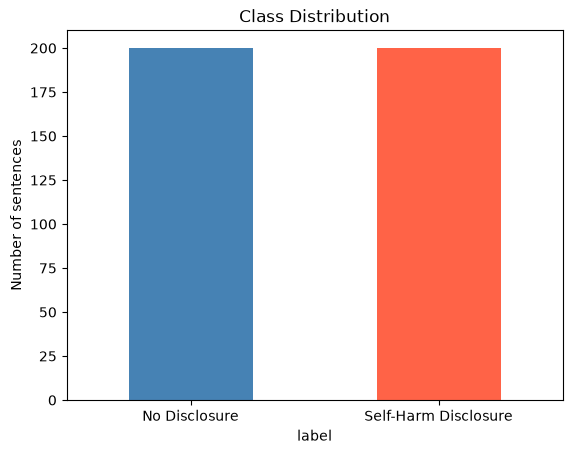

In [4]:
print("Dataset shape:", df.shape)
print("Duplicate texts:", df["text"].str.strip().str.lower().duplicated().sum())
print("\nLabels:")
print(df["label"].value_counts().sort_index())
print("\nSplits:")
print(pd.crosstab(df["split"], df["label"]))

df["label"].value_counts().sort_index().plot(
    kind="bar",
    color=["steelblue", "tomato"],
)
plt.xticks([0, 1], ["No Disclosure", "Self-Harm Disclosure"], rotation=0)
plt.ylabel("Number of sentences")
plt.title("Class Distribution")
plt.show()


## Use dataset splits

In [5]:
train_df = df[df["split"] == "train"].sample(frac=1, random_state=SEED)
val_df = df[df["split"] == "validation"].sample(frac=1, random_state=SEED)
test_df = df[df["split"] == "test"].sample(frac=1, random_state=SEED)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))


Training samples: 272
Validation samples: 64
Test samples: 64


## Load tokenizer and model

In [6]:
id2label = {0: "NO_SELF_HARM_DISCLOSURE", 1: "SELF_HARM_DISCLOSURE"}
label2id = {"NO_SELF_HARM_DISCLOSURE": 0, "SELF_HARM_DISCLOSURE": 1}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Tokenize dataset

In [7]:
def tokenize_data(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

train_dataset = train_dataset.map(tokenize_data, batched=True)
val_dataset = val_dataset.map(tokenize_data, batched=True)
test_dataset = test_dataset.map(tokenize_data, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/272 [00:00<?, ? examples/s]

Map: 100%|██████████| 272/272 [00:00<00:00, 33174.87 examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

Map: 100%|██████████| 64/64 [00:00<00:00, 18279.57 examples/s]

Map:   0%|          | 0/64 [00:00<?, ? examples/s]

Map: 100%|██████████| 64/64 [00:00<00:00, 18412.47 examples/s]

## Evaluation metrics

In [8]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


## Train model

In [9]:
training_args = TrainingArguments(
    output_dir="./self_harm_training_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.588600,0.261599,0.921875,0.864865,1.000000,0.927536
2,0.080000,0.471302,0.906250,0.842105,1.000000,0.914286
3,0.027400,0.019772,0.984375,0.969697,1.000000,0.984615
4,0.005900,0.024537,0.984375,0.969697,1.000000,0.984615
5,0.000500,0.047489,0.984375,0.969697,1.000000,0.984615


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=170, training_loss=0.14047664021525313, metrics={'train_runtime': 24.5979, 'train_samples_per_second': 110.578, 'train_steps_per_second': 13.822, 'total_flos': 4890944734752.0, 'train_loss': 0.14047664021525313, 'epoch': 5.0})

## Training history

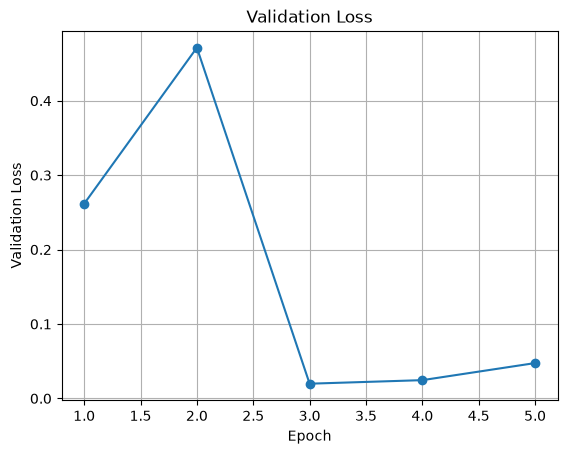

Best checkpoint: ./self_harm_training_output/checkpoint-102
Best validation F1: 0.9846153846153847


In [10]:
history = pd.DataFrame(trainer.state.log_history)
validation_history = history.dropna(subset=["eval_loss"])

plt.plot(validation_history["epoch"], validation_history["eval_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss")
plt.grid(True)
plt.show()

print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation F1:", trainer.state.best_metric)


## Evaluate on test data

/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.37939536571502686, 'eval_accuracy': 0.9375, 'eval_precision': 0.9117647058823529, 'eval_recall': 0.96875, 'eval_f1': 0.9393939393939394, 'eval_runtime': 0.1459, 'eval_samples_per_second': 438.596, 'eval_steps_per_second': 54.825, 'epoch': 5.0}


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


                         precision    recall  f1-score   support

No Self-Harm Disclosure       0.97      0.91      0.94        32
   Self-Harm Disclosure       0.91      0.97      0.94        32

               accuracy                           0.94        64
              macro avg       0.94      0.94      0.94        64
           weighted avg       0.94      0.94      0.94        64



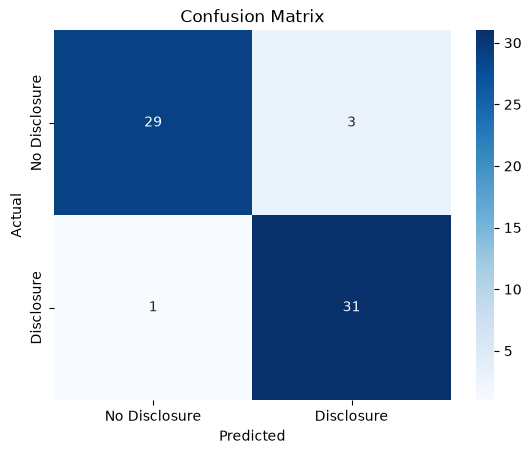

In [11]:
test_results = trainer.evaluate(test_dataset)
print(test_results)

test_predictions = trainer.predict(test_dataset)
y_pred = np.argmax(test_predictions.predictions, axis=-1)
y_true = test_predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["No Self-Harm Disclosure", "Self-Harm Disclosure"],
))

matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disclosure", "Disclosure"],
    yticklabels=["No Disclosure", "Disclosure"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Save model

In [12]:
MODEL_PATH = "./self_harm_model_v2"
trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)
print("Model saved to:", MODEL_PATH)


Model saved to: ./self_harm_model_v2


## Try some examples

In [13]:
classifier = pipeline(
    "text-classification",
    model=MODEL_PATH,
    tokenizer=MODEL_PATH,
)

examples = [
    "I feel like hurting myself tonight.",
    "I do not want to live anymore.",
    "I had a stressful day, but I will be okay.",
    "I am writing a report about suicide prevention.",
    "I accidentally cut my finger while cooking.",
]

for text in examples:
    result = classifier(text)[0]
    print(text)
    print(result)
    print()


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


I feel like hurting myself tonight.
{'label': 'SELF_HARM_DISCLOSURE', 'score': 0.9994828701019287}

I do not want to live anymore.
{'label': 'SELF_HARM_DISCLOSURE', 'score': 0.9995549321174622}

I had a stressful day, but I will be okay.
{'label': 'SELF_HARM_DISCLOSURE', 'score': 0.742883563041687}

I am writing a report about suicide prevention.
{'label': 'NO_SELF_HARM_DISCLOSURE', 'score': 0.9994183778762817}

I accidentally cut my finger while cooking.
{'label': 'NO_SELF_HARM_DISCLOSURE', 'score': 0.9993112087249756}

